In [161]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error

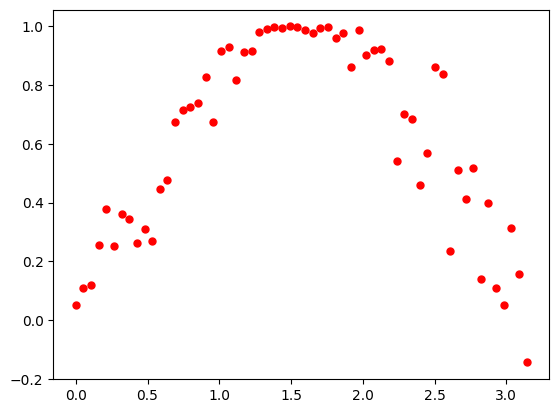

In [41]:
# Generate a sine scatter
n_points = 60
min_x_range = 0
max_x_range = np.pi

# X_base = np.random.uniform(low=min_x_range, high=max_x_range, size=n_points)
X_base = np.linspace(start=min_x_range, stop=max_x_range, num=n_points)
noise = np.random.normal(loc=0, scale=0.15, size=n_points)

Y_base = np.sin(X_base + noise)

ax = plt.subplot()
ax.scatter(x=X_base, y=Y_base, c='r', s=25)
plt.show()

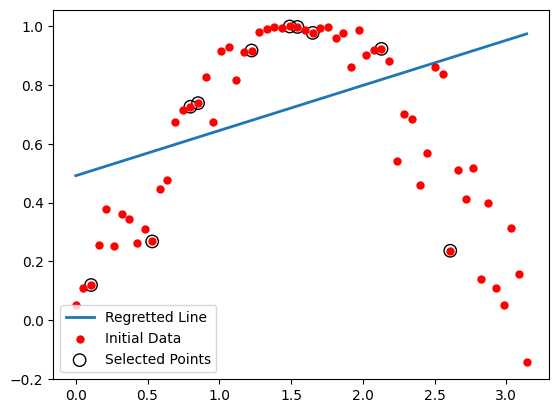

In [179]:
n_degree = 1
n_sample = 10

ls_index = np.arange(60)
ls_random_positions = np.random.choice(a=ls_index, size=n_sample, replace=False)
X_pick = [X_base[i] for i in ls_random_positions]
Y_pick = [Y_base[i] for i in ls_random_positions]

# Fits a line on x_array and y_array and returns coefficients of the fitted line
# y = m * x^1 + b * x^0
ls_coefficients = np.polyfit(x=X_pick, y=Y_pick, deg=n_degree)

# generate points to plot the fitted line
x_fit = np.linspace(min_x_range, max_x_range, 100)
y_fit = sum([ls_coefficients[i] * (x_fit ** (n_degree - i)) for i in np.arange(n_degree + 1)])

ax = plt.subplot()
ax.plot(x_fit, y_fit, lw=2, label='Regretted Line')
ax.scatter(X_base, Y_base, c='r', zorder=2, s=25, label='Initial Data')
ax.scatter(X_pick, Y_pick, s=80, facecolors='none', edgecolors='k', label='Selected Points')
plt.legend(loc='best')
# plt.ylim(-1.5, 1.5)
plt.show()

# Let's do it with polynomials...

What does PolynomialFeatures do?

x^2 could be considered as a new feature like U, so everything would remain a linear regression!

    y = a x^2 + b x + c
    U = x^2
    y = a U + b x + c

In [130]:
# poly_deg_2_test = PolynomialFeatures(degree=2, include_bias=False)
# poly_deg_2_test.fit_transform(X_base.reshape(-1, 1))

X_base_new = X_base.reshape(-1, 1) - 2
X_2_features = np.concatenate((X_base.reshape(-1, 1), X_base_new), axis=1)
# X_2_features

#    x1   |   x2   |   x1^2   |   x1 * x2   |   x2^2
poly_deg_2_test = PolynomialFeatures(degree=2, include_bias=False)
# poly_deg_2_test.fit_transform(X_2_features)

# https://data36.com/polynomial-regression-python-scikit-learn/

In [131]:
# Creating a linear regression model
lin_reg_model = LinearRegression()

# Creating higher order features from the first degree feature
poly_deg_2 = PolynomialFeatures(degree=2, include_bias=False)
poly_2_features = poly_deg_2.fit_transform(X_base.reshape(-1, 1))

# Fitting and predicting
lin_reg_model.fit(X=poly_2_features, y=Y_base)
y_predicted = lin_reg_model.predict(poly_2_features)

# R-Squared Using SKLearn Metrics
r2 = r2_score(y_true=Y_base, y_pred=y_predicted)
print(f'R-Squared for the 2nd order polynomial model:\t{round(r2, 3)}')

R-Squared for the 2nd order polynomial model:	0.876


In [132]:
max_degree = 10

for i in range(max_degree):
    lin_reg_model = LinearRegression()
    poly_instance = PolynomialFeatures(degree=i + 1, include_bias=False)
    poly_features = poly_instance.fit_transform(X_base.reshape(-1, 1))
    
    lin_reg_model.fit(poly_features, Y_base)
    y_predicted = lin_reg_model.predict(poly_features)
    
    r2 = r2_score(y_true=Y_base, y_pred=y_predicted)
    print(f'R-Squared for the polynomial model of order={i + 1}:\t{round(r2, 2)}')

R-Squared for the polynomial model of order=1:	0.0
R-Squared for the polynomial model of order=2:	0.88
R-Squared for the polynomial model of order=3:	0.88
R-Squared for the polynomial model of order=4:	0.89
R-Squared for the polynomial model of order=5:	0.89
R-Squared for the polynomial model of order=6:	0.89
R-Squared for the polynomial model of order=7:	0.89
R-Squared for the polynomial model of order=8:	0.9
R-Squared for the polynomial model of order=9:	0.9
R-Squared for the polynomial model of order=10:	0.9


# How does the model perform on unseen data?

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X_base, Y_base, train_size=0.75, random_state=0)

len(X_train), len(X_test), len(y_train), len(y_test)

(45, 15, 45, 15)

In [177]:
# Hyper-parameter tuning

poly_instance = PolynomialFeatures(degree=10, include_bias=False)
poly_features = poly_instance.fit_transform(X_base.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(
    poly_features,
    Y_base,
    train_size=0.75,
)

# Fitting the model only on "train" data
lin_reg_model = LinearRegression(fit_intercept=True)
lin_reg_model.fit(X_train, y_train)
y_predicted = lin_reg_model.predict(X_train)

r2 = r2_score(y_true=y_train, y_pred=y_predicted)
print(f'R-Squared:\t{round(r2, 3)}')

R-Squared:	0.891


Now I can decide:
* The degree of the regression 
* Whether using fit_intercept or not

In [180]:
# Giving the model what it hasn't seen before :)
y_pred = lin_reg_model.predict(X_test)

r2 =    r2_score(y_true=y_test, y_pred=y_pred)
mse =   mean_squared_error(y_true=y_test , y_pred=y_pred)
rmse =  root_mean_squared_error(y_true=y_test , y_pred=y_pred)
mae =   mean_absolute_error(y_true=y_test , y_pred=y_pred)

print(f'MSE:\t\t{round(mse, 3)}')
print(f'RMSE:\t\t{round(rmse, 3)}')
print(f'MSE:\t\t{round(mae, 3)}')
print(f'R-Squared:\t{round(r2, 3)}')

MSE:		0.244
RMSE:		0.494
MSE:		0.197
R-Squared:	-1.108
